y=x\*\*2  
when x =5  
dy/dx = 2x = 2(5) = 10


In [522]:
import torch

x=torch.tensor(5.0)
x.requires_grad_()

y=x**2

y.backward()


x.grad

tensor(10.)

### Fitting the y=mx+b using ML


In [523]:
import matplotlib.pyplot as plt

x=torch.tensor([0,1,2,3,4,5,6,7.])
x

tensor([0., 1., 2., 3., 4., 5., 6., 7.])

In [524]:
# y=torch.tensor([1.8,1.31,0.63,0.33,.09,-.67,-1.23,-1.37])
y = -0.5*x +2+torch.tensor([torch.rand(1) for i in range(8)])
y

tensor([ 2.6665,  1.7515,  1.0886,  0.8980,  0.6238,  0.0485, -0.6590, -1.4808])

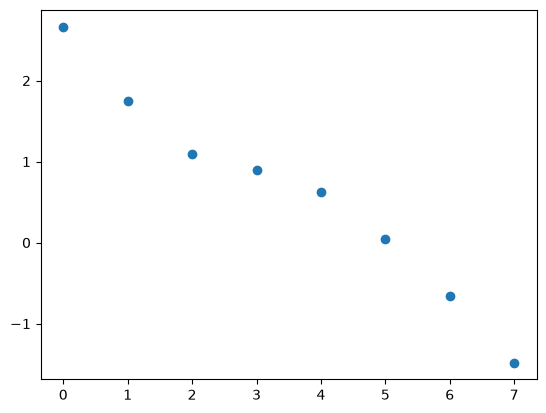

In [525]:
fig,ax = plt.subplots()
_=ax.scatter(x,y)

In [526]:
m=torch.tensor([1.01]).requires_grad_()
m

tensor([1.0100], requires_grad=True)

In [527]:
b=torch.tensor([0.4]).requires_grad_()
b

tensor([0.4000], requires_grad=True)

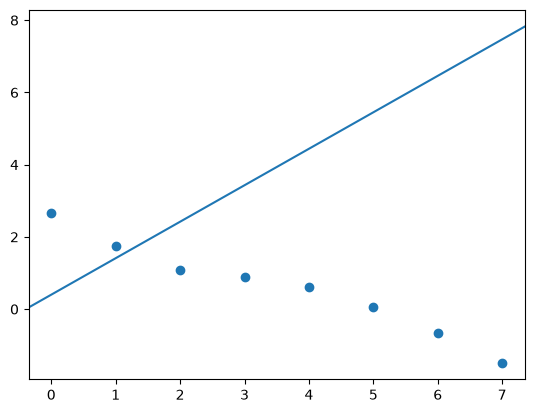

In [528]:
def reg_plot(my_x,my_y,my_m,my_b):
    fig,ax = plt.subplots()
    
    ax.scatter(my_x,my_y)
    
    x_min,x_max = ax.get_xlim()
    y_min,y_max = my_m*x_min + my_b,my_m*x_max + my_b
    ax.set_xlim([x_min,x_max])
    ax.plot([x_min,x_max],[y_min.detach().numpy(),y_max.detach().numpy()])
    



reg_plot(x,y,m,b)

In [529]:
def reggression(my_m,my_x,my_b):
    return my_m*my_x+my_b

y_hat=reggression(x,m,b)
y_hat

tensor([0.4000, 1.4100, 2.4200, 3.4300, 4.4400, 5.4500, 6.4600, 7.4700],
       grad_fn=<AddBackward0>)

mean squared error (mse) = 1/n(sigma ( y_hat - y ))


In [530]:
def mse(my_yhat,my_y):
    sigma = torch.sum((my_yhat-my_y)**2)

    return sigma/len(my_y)
C = mse(y_hat,y)
C

tensor(23.4965, grad_fn=<DivBackward0>)

In [531]:
C.backward()
m.grad,b.grad

(tensor([39.3896]), tensor([6.6357]))

In [532]:
optimizer = torch.optim.SGD([m,b],lr=0.01)
optimizer.step()
m,b

(tensor([0.6161], requires_grad=True), tensor([0.3336], requires_grad=True))

In [533]:
mse(reggression(m,x,b),y)


tensor(10.4434, grad_fn=<DivBackward0>)

Epoch:0, Cost 10.44335651397705, m grad 25.13875389099121, b grad 3.745699644088745,
Epoch:200, Cost 0.19954949617385864, m grad 0.08393514156341553, b grad -0.41276270151138306,
Epoch:400, Cost 0.06091663986444473, m grad 0.02640587091445923, b grad -0.12985706329345703,
Epoch:600, Cost 0.04719528555870056, m grad 0.008307069540023804, b grad -0.04085320234298706,
Epoch:800, Cost 0.04583724960684776, m grad 0.0026129186153411865, b grad -0.01285293698310852,
Epoch:1000, Cost 0.04570282995700836, m grad 0.0008238255977630615, b grad -0.004042893648147583,


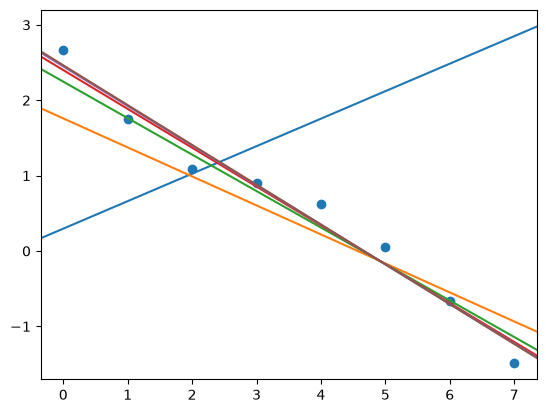

In [534]:

epochs = 1001
fig,ax = plt.subplots()

ax.scatter(x,y)

for epoch in range(epochs):
    
    optimizer.zero_grad() # resets gradients to zero 
    
    y_hat = reggression(x,m,b) # step 1
    C = mse(y_hat,y)
    
    C.backward() # auto diff
    optimizer.step() # adjust the values 
    if epoch %200 ==0:
        x_min ,x_max = ax.get_xlim()
        ax.set_xlim([x_min,x_max])
        y_min,y_max = m*x_min+b,m*x_max +b
        
        _=ax.plot([x_min,x_max],[y_min.detach().numpy(),y_max.detach().numpy()]) 
        print(f"Epoch:{epoch}, Cost {C.item()}, m grad {m.grad.item()}, b grad {b.grad.item()},") 
    

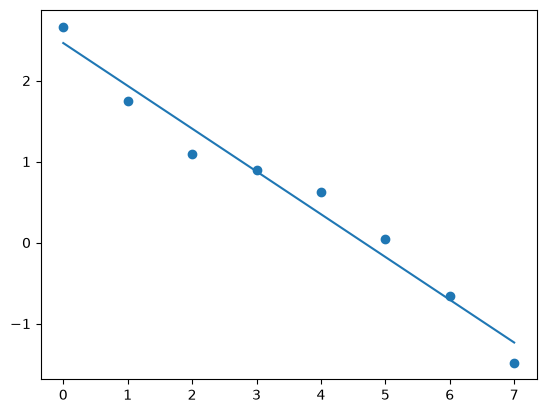

In [535]:
y_assumed=m*x+b

fig,ax = plt.subplots()

ax.scatter(x,y)

_=ax.plot(x,y_assumed.detach().numpy())

In [536]:
m.item(),b.item()

(-0.5280787348747253, 2.4634225368499756)